## 1. Diagnóstico del Agente Base

El primer paso para proponer una mejora sustancial en el modelo propuesto consiste en analizar como se realizó la implementación del agente base entrenado mediante Q-Learning. Al inspeccionar la arquitectura, el bucle de entrenamiento y el modo de inferencia, se identificaron diversas fallas que impiden que el agente alcance un alto desempeño. 

A continuación, se presenta el análisis detallado respondiendo a los tres interrogantes clave sobre su comportamiento.


### 1.1 ¿Por qué pierde?

El agente registra derrotas sistemáticas, incluso después de miles de episodios de entrenamiento, debido a dos errores críticos en la fase de evaluación y en la formulación de como interactúa el agente con el oponente

* **Exploración activa durante la inferencia:** En la función on_click, el agente selecciona su acción llamando a choose_action(s). Esta función utiliza una probabilidad de exploración fija de **epsilon = 0.2**. Esto significa que el 20% de las veces el agente ignora por completo su tabla Q y realiza un movimiento aleatorio. Al no cambiar a una política más exacta durante la evaluación, el agente puede llegar a desperdiciar 1 de cada 5 jugadas.
* **Incapacidad de anticipación:** La regla de actualización de Q-Learning asume que el siguiente estado le permitirá al agente tomar la mejor acción posible para maximizar su recompensa futura. Sin embargo, en un juego por turnos, el estado inmediatamente siguiente le pertenece al oponente. Al ignorar que el oponente jugará para minimizar la recompensa del agente, el algoritmo toma decisiones subóptimas.


### 1.2 ¿Por qué no converge?

Debido a que la tasa de aprendizaje `alpha = 0.1` y la tasa de exploración `epsilon = 0.2` se mantienen constantes a lo largo de todos los episodios. Para garantizar la convergencia en métodos tabulares, la exploración debe decaer asintóticamente hacia cero. Al mantener un ruido aleatorio constante, los valores Q nunca logran estabilizarse. Además, en la función train(), las jugadas del agente (X) y del oponente (O) comparten exactamente la misma tabla Q para la toma de decisiones y la actualización de valores. Dado que ganar con X otorga una recompensa de +1 y ganar con O otorga -1, la tabla se contradice. El oponente O, al buscar maximizar el valor Q, termina eligiendo las jugadas que le convienen a X.


### 1.3 ¿Por qué aprende lentamente?

Asumiendo que se corrigiera la corrupción de la tabla Q, la velocidad de propagación del error y la asignación de crédito (Credit Assignment) siguen siendo altamente ineficientes:

* Solo hay recompensa al final del episodio. No hay recompensas intermedias (por ejemplo, +0.1 por bloquear o -0.1 por dejar una línea abierta al oponente).

* El agente no recibe señal de aprendizaje hasta que termina la partida. En juegos como triqui, la mayoría de las secuencias de movimientos aleatorios terminan en empate o derrota, por lo que el agente recibe muchos episodios con recompensa ≤0 antes de encontrar una victoria.

In [ ]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt


# 1. REPRODUCIBILIDAD Y DEFINICIONES BÁSICAS

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)

EMPTY = 0
X = 1
O = -1

def initial_state():
    return np.zeros((3, 3), dtype=int)

def available_actions(state):
    return [(i, j) for i in range(3) for j in range(3) if state[i, j] == EMPTY]

def check_winner(state):
    for i in range(3):
        if abs(sum(state[i, :])) == 3: return np.sign(sum(state[i, :]))
        if abs(sum(state[:, i])) == 3: return np.sign(sum(state[:, i]))

    diag1 = state[0,0] + state[1,1] + state[2,2]
    diag2 = state[0,2] + state[1,1] + state[2,0]
    
    if abs(diag1) == 3:
        return np.sign(diag1)
    if abs(diag2) == 3:
        return np.sign(diag2)
    
    if not available_actions(state):
        return 0
    
    return None

def state_to_tuple(state):
    return tuple(state.flatten())


# 2. DEFINICIÓN Y ENTRENAMIENTO DEL AGENTE BASE 

class BaseQAgent:
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.Q = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def get_Q(self, state, action):
        return self.Q.get((state, action), 0.0)

    def choose_action(self, state_arr):
        actions = available_actions(state_arr)
        
        
        if random.random() < self.epsilon:
            return random.choice(actions)
        
        s_tuple = state_to_tuple(state_arr)
        qs = [self.get_Q(s_tuple, a) for a in actions]
        max_q = max(qs)

        return actions[qs.index(max_q)]

    def update_Q(self, state, action, reward, next_state):
        actions = available_actions(np.array(next_state).reshape(3,3))
    
        max_q_next = 0 if not actions else max(
            [self.get_Q(next_state, a) for a in actions]
        )
        
        old_q = self.get_Q(state, action)
        
        self.Q[(state, action)] = old_q + self.alpha * (reward + self.gamma * max_q_next - old_q)



def train_base_agent(episodes=10000):
    set_seeds(42)
    base_agent = BaseQAgent()
    for _ in range(episodes):
        state = initial_state()
        current_player = X
        while True:
            s = state_to_tuple(state)
            action = base_agent.choose_action(state)
            state[action] = current_player
            result = check_winner(state)
            s_next = state_to_tuple(state)
            if result is not None:
                reward = 1 if result == X else (-1 if result == O else 0)
                base_agent.update_Q(s, action, reward, s_next)
                break
            else:
                base_agent.update_Q(s, action, 0, s_next)
            current_player *= -1
    return base_agent

## 2. Rediseño del Agente: Enfoque A (Mejora de Q-Learning)

Para solucionar los fallos encontrados en el agente base, se propone un rediseño de la arquitectura de Q-Learning. 

Las mejoras implementadas se sustentan en tres pilares:

### 2.1 Mejora de la Estrategia de Exploración (Decaimiento de Epsilon)
Mantener una tasa de exploración fija (`epsilon = 0.2`) impide que el algoritmo estabilice su política, provocando oscilaciones permanentes en los valores Q y forzando al agente a cometer errores aleatorios durante la evaluación. Para solucionar esto, se implementó una estrategia de decaimento exponencial de epsilon. Durante las primeras fases del entrenamiento, el agente explora con mayor amplitud el espacio de estados ($\epsilon \approx 1.0$). A medida que avanzan los episodios, la probabilidad de explorar decae asintóticamente hacia un valor mínimo ($\epsilon_{min} = 0.0$). 

Esto garantiza que se descubra suficiente información al inicio y se asegura la convergencia teórica hacia una política en la que el agente no toma decisiones al azar.

### 2.2 Rediseño de la Función de Recompensa y Transición del MDP
El agente base actualizaba su tabla Q turno a turno, asumiendo erróneamente que el estado siguiente le pertenecía a él, e ignorando el valor estratégico de un empate. Además, corrompía su propia tabla al entrenar el símbolo `O` sobre los mismos valores de `X`. Para abordar esta problemática se redefinió la transición del MDP. Un paso completo del agente `X` ahora se define como: el estado actual $S$, la acción del agente $A$, la respuesta inmediata del oponente, y el estado resultante $S_{next}$ tras la jugada enemiga. También se ajustó la función de recompensa para asignar un valor positivo al empate. Si un empate otorga 0, el agente puede preferir arriesgarse a perder intentando buscar una victoria imposible. Recompensar el empate premia al agente por jugar de forma defensiva. Al incluir la respuesta del oponente dentro de la misma transición de actualización, la Ecuación de Bellman anticipa correctamente las amenazas enemigas (se elimina la miopía adversaria).


### 2.3 Ajuste de Hiperparámetros y Entrenamiento Aislado
* Se establece un factor de descuento `gamma = 0.99` para darle máxima prioridad a las consecuencias a largo plazo (evitar trampas del oponente).
* Se elimina el "Self-Play" destructivo: el agente `X` ahora entrena contra un oponente automatizado independiente (que puede ser aleatorio o heurístico) que no sobrescribe la tabla Q del agente, permitiendo una convergencia estable.

In [ ]:
# 3. DEFINICIÓN DEL AGENTE REDISEÑADO (Enfoque A)
class ImprovedQAgent:
    def __init__(self, alpha=0.1, gamma=0.99, epsilon_start=1.0, epsilon_end=0.0, epsilon_decay=0.9998):
        self.Q = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_end
        self.epsilon_decay = epsilon_decay

    def get_Q(self, state, action):
        return self.Q.get((state, action), 0.0)

    def choose_action(self, state_arr, is_eval=False):
        actions = available_actions(state_arr)
        if not actions: return None
        current_epsilon = 0.0 if is_eval else self.epsilon
        if random.random() < current_epsilon:
            return random.choice(actions)
        s_tuple = state_to_tuple(state_arr)
        qs = [self.get_Q(s_tuple, a) for a in actions]
        max_q = max(qs)
        best_actions = [a for a, q in zip(actions, qs) if q == max_q]
        return random.choice(best_actions)

    def update_Q(self, state_tuple, action, reward, next_state_tuple, done):
        old_q = self.get_Q(state_tuple, action)
        if done:
            max_q_next = 0.0
        else:
            next_state_arr = np.array(next_state_tuple).reshape(3, 3)
            actions = available_actions(next_state_arr)
            max_q_next = max([self.get_Q(next_state_tuple, a) for a in actions]) if actions else 0.0
        self.Q[(state_tuple, action)] = old_q + self.alpha * (reward + self.gamma * max_q_next - old_q)

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
            self.epsilon = max(self.epsilon_min, self.epsilon)


def train_improved_agent(episodes=50000):
    set_seeds(42)
    agent = ImprovedQAgent()
    history_eps, history_wins, history_losses = [], [], []
    
    print(f"Entrenando Agente Mejorado ({episodes} episodios)")
    for episode in range(1, episodes + 1):
        state = initial_state()
        
        #  En episodios impares entrena como X, en pares como O
        agent_piece = X if episode % 2 != 0 else O
        opp_piece = O if agent_piece == X else X
        
        # Si al agente le toca defender (O), el oponente hace el primer movimiento
        if agent_piece == O:
            opp_action = random.choice(available_actions(state))
            state[opp_action] = opp_piece
            
        while True:
            # TURNO DEL AGENTE
            s_tuple = state_to_tuple(state)
            action = agent.choose_action(state, is_eval=False)
            state[action] = agent_piece
            
            result = check_winner(state)
            if result is not None:
                # Recompensa si gana el agente
                if result == agent_piece: reward = 1.0
                elif result == 0: reward = 0.5
                else: reward = -1.0
                
                agent.update_Q(s_tuple, action, reward, state_to_tuple(state), done=True)
                break
                
            # TURNO DEL OPONENTE (Aleatorio)
            opp_action = random.choice(available_actions(state))
            state[opp_action] = opp_piece
            
            result = check_winner(state)
            next_s_tuple = state_to_tuple(state)
            
            if result is not None:
                if result == opp_piece: reward = -1.0
                elif result == 0: reward = 0.5
                else: reward = 1.0
                
                agent.update_Q(s_tuple, action, reward, next_s_tuple, done=True)
                break
            else:
                agent.update_Q(s_tuple, action, 0.0, next_s_tuple, done=False)
                
        agent.decay_epsilon()
        
        # Guardar métricas de convergencia
        if episode % 2500 == 0:
            w, l = 0, 0
            for _ in range(500):
                st = initial_state()
                cp = X
                while True:
                    acts = available_actions(st)
                    if not acts: break
                    if cp == X: act = agent.choose_action(st, is_eval=True)
                    else: act = random.choice(acts)
                    st[act] = cp
                    res = check_winner(st)
                    if res is not None:
                        if res == X: w += 1
                        elif res == O: l += 1
                        break
                    cp *= -1
            history_eps.append(episode)
            history_wins.append(w / 500)
            history_losses.append(l / 500)
            
    return agent, history_eps, history_wins, history_losses


## 3. Protocolo Experimental y Evaluación de Métricas

Para demostrar experimentalmente la superioridad del agente rediseñado, se implementa un protocolo de pruebas basado en los requerimientos metodológicos del taller. El objetivo es someter al agente a un volumen masivo de partidas bajo condiciones controladas para extraer conclusiones con validez estadística.

### 3.1 Escenarios de Evaluación
#### 3.1.1 Grupo 1: Desempeño del Agente Mejorado vs Aleatorio
* Escenario 1 (Inicia Mejorado [X] vs Aleatorio [O])
* Escenario 2 (Inicia Aleatorio [X] vs Mejorado [O])

#### 3.1.2 Grupo 2: Enfrentamiento Directo (Mejorado vs Base)
* Escenario 3 (Mejorado vs Base - Ambos Inicios)
#### 3.1.3 Grupo 3: Línea Base de Control (Agente Base vs Aleatorio)
* Escenario 4 (Inicia Base [X] vs Aleatorio [O])
* Escenario 5 (Inicia Aleatorio [X] vs Base [O])


### 3.2 Reproducibilidad
Se fija una semilla de control (`seed = 42`) al inicio de cada evaluación para garantizar la total reproducibilidad de las métricas y visualizaciones.


### 3.3 Métricas de Evaluación Formarles
El desempeño del modelo se cuantifica mediante las siguientes métricas:
* **Tasa de victoria (Win Rate):** Se calcula la proporción de éxitos mediante la relación de victorias sobre el total de partidas:
  $$\text{Win Rate} = \frac{\text{Victorias}}{\text{Total de partidas}}$$
* **Distribución de resultados:** Se extrae el porcentaje exacto de victorias, empates y derrotas. Un agente perfecto en el juego de triqui debe minimizar las derrotas estrictamente a $0\%$.
* **Velocidad de aprendizaje:** Se analiza la evolución del rendimiento versus la cantidad de episodios transcurridos para identificar el número de episodios exacto en el que ocurre la estabilización.
* **Eficiencia y Resultados Visibles:** Se mide el tiempo de entrenamiento e inferencia, presentando los datos mediante gráficas y métricas obtenidas para hacer completamente visibles los resultados de la ejecución.

In [ ]:

# 4. PROTOCOLO DE EVALUACIÓN

def evaluate_versus(agent_x, agent_o, games=10000):
    """
    Enfrenta a dos agentes de forma segura. Si uno es None, juega aleatorio.
    Detecta automáticamente la firma de inferencia correcta según la clase.
    """
    wins_x, draws, wins_o = 0, 0, 0
    start_time = time.time()
    
    for _ in range(games):
        state = initial_state()
        current_player = X
        
        while True:
            actions = available_actions(state)
            if not actions:
                draws += 1
                break
                
            current_agent = agent_x if current_player == X else agent_o
            
            if current_agent is None:
                action = random.choice(actions)
            elif isinstance(current_agent, ImprovedQLearningAgent):
                # Inferencia pura sin errores: fuerza política greedy
                action = current_agent.choose_action(state, is_eval=True)
            else:
                # Agente base: usa su método original de 1 solo parámetro
                action = current_agent.choose_action(state)
                
            state[action] = current_player
            result = check_winner(state)
            
            if result is not None:
                if result == X: wins_x += 1
                elif result == 0: draws += 1
                else: wins_o += 1
                break
                
            current_player *= -1
            
    exec_time = time.time() - start_time
    return wins_x, draws, wins_o, exec_time

Entrenando Agente Base de clase (10k episodios)...
Entrenando Agente Mejorado (50000 episodios para AMBOS roles)...

Ejecutando 60,000 partidas de evaluación (10k por escenario)...

 RESULTADOS FINALES DE EVALUACIÓN (10,000 PARTIDAS POR ESCENARIO)
 GRUPO 1: Agente Mejorado vs Aleatorio
  E1 (Mejorado inicia):   Victorias: 95.3% | Empates: 4.7% | Derrotas: 0.0%
  E2 (Aleatorio inicia):  Victorias: 78.2% | Empates: 17.5% | Derrotas: 4.3%
-------------------------------------------------------------------------------------
 GRUPO 2: Enfrentamiento Directo (Mejorado vs Base)
  E3 (Mejorado inicia):   Victorias: 97.6% | Empates: 2.4% | Derrotas: 0.0%
  E4 (Base inicia):       Victorias: 90.2% | Empates: 9.5% | Derrotas: 0.3%
-------------------------------------------------------------------------------------
 GRUPO 3: Control Línea Base (Agente Base vs Aleatorio)
  E5 (Base inicia):       Victorias: 79.3% | Empates: 4.0% | Derrotas: 16.6%
  E6 (Aleatorio inicia):  Victorias: 23.8% | Empate

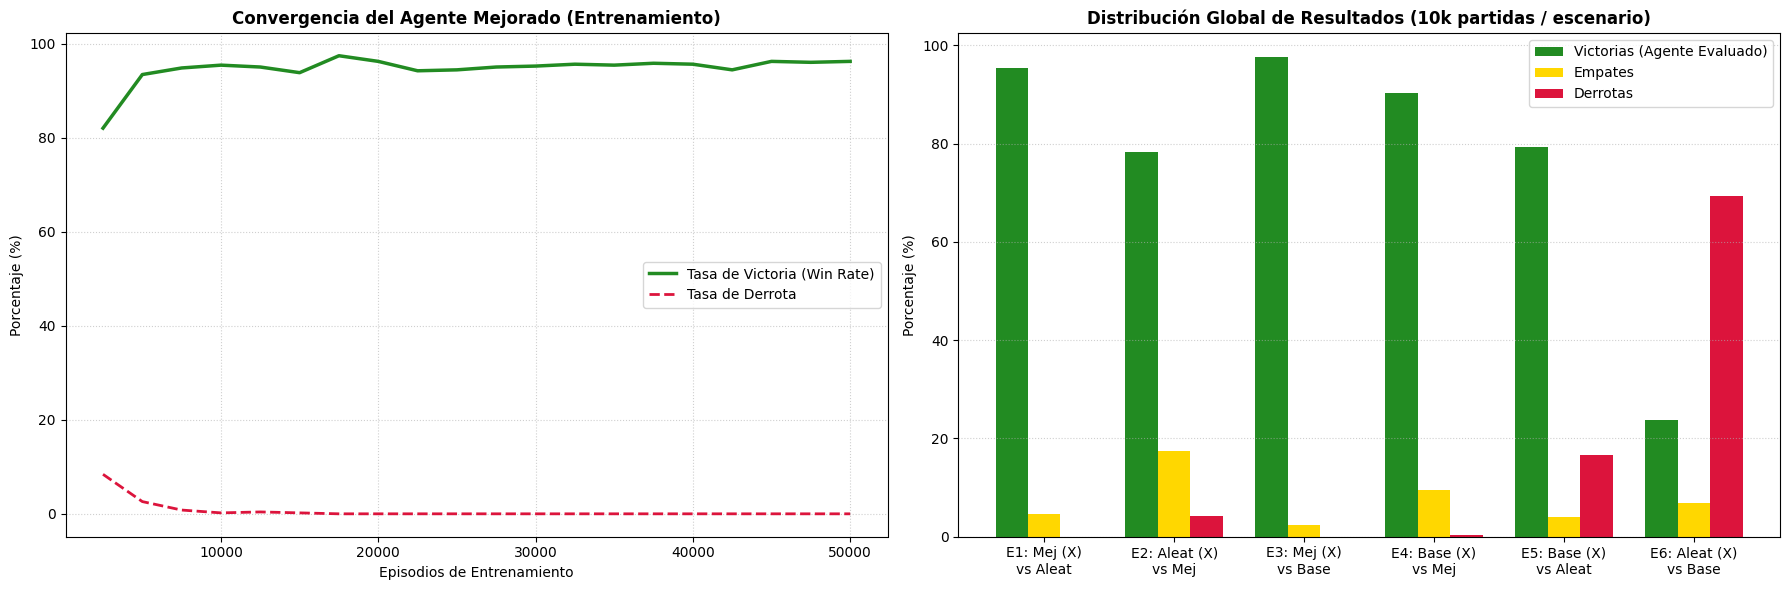

In [ ]:

# 5. ENTRENAMIENTO DE AGENTES Y EJECUCIÓN DE LA EVALUACIÓN

print("Entrenando Agente Base de clase (10k episodios)...")
base_agent = train_base_agent(episodes=10000)
improved_agent, eps_hist, w_hist, l_hist = train_improved_agent(episodes=50000)

print("\nEjecutando 60,000 partidas de evaluación (10k por escenario)...")

# ESCENARIO 1: Mejorado (X) vs Aleatorio (O) 
set_seeds(42)
w1, d1, l1, _ = evaluate_versus(improved_agent, None, games=10000)

# ESCENARIO 2: Aleatorio (X) vs Mejorado (O)

set_seeds(42)
l2, d2, w2, _ = evaluate_versus(None, improved_agent, games=10000)

# ESCENARIO 3: Mejorado (X) vs Base (O) 
set_seeds(42)
w3, d3, l3, _ = evaluate_versus(improved_agent, base_agent, games=10000)

# ESCENARIO 4: Base (X) vs Mejorado (O) 
# 
set_seeds(42)
l4, d4, w4, _ = evaluate_versus(base_agent, improved_agent, games=10000)

# ESCENARIO 5: Base (X) vs Aleatorio (O)
set_seeds(42)
w5, d5, l5, _ = evaluate_versus(base_agent, None, games=10000)

# ESCENARIO 6: Aleatorio (X) vs Base (O)
set_seeds(42)
l6, d6, w6, _ = evaluate_versus(None, base_agent, games=10000)

# IMPRIMIR TABLA DE RESULTADOS 
print("\n" + "="*85)
print(" RESULTADOS FINALES DE EVALUACIÓN (10,000 PARTIDAS POR ESCENARIO)")
print("="*85)
print(" GRUPO 1: Agente Mejorado vs Aleatorio")
print(f"  E1 (Mejorado inicia):   Victorias: {w1/100:.1f}% | Empates: {d1/100:.1f}% | Derrotas: {l1/100:.1f}%")
print(f"  E2 (Aleatorio inicia):  Victorias: {w2/100:.1f}% | Empates: {d2/100:.1f}% | Derrotas: {l2/100:.1f}%")
print("-" * 85)
print(" GRUPO 2: Enfrentamiento Directo (Mejorado vs Base)")
print(f"  E3 (Mejorado inicia):   Victorias: {w3/100:.1f}% | Empates: {d3/100:.1f}% | Derrotas: {l3/100:.1f}%")
print(f"  E4 (Base inicia):       Victorias: {w4/100:.1f}% | Empates: {d4/100:.1f}% | Derrotas: {l4/100:.1f}%")
print("-" * 85)
print(" GRUPO 3: Control Línea Base (Agente Base vs Aleatorio)")
print(f"  E5 (Base inicia):       Victorias: {w5/100:.1f}% | Empates: {d5/100:.1f}% | Derrotas: {l5/100:.1f}%")
print(f"  E6 (Aleatorio inicia):  Victorias: {w6/100:.1f}% | Empates: {d6/100:.1f}% | Derrotas: {l6/100:.1f}%")
print("="*85)

# GENERAR GRÁFICAS 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Gráfica 1: Curva de Estabilización
ax1.plot(eps_hist, np.array(w_hist)*100, label='Tasa de Victoria (Win Rate)', color='forestgreen', lw=2.5)
ax1.plot(eps_hist, np.array(l_hist)*100, label='Tasa de Derrota', color='crimson', lw=2, linestyle='--')
ax1.set_title('Convergencia del Agente Mejorado (Entrenamiento)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Episodios de Entrenamiento')
ax1.set_ylabel('Porcentaje (%)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Gráfica 2: Comparativa Global de los 6 Escenarios
labels = [
    'E1: Mej (X)\nvs Aleat', 
    'E2: Aleat (X)\nvs Mej', 
    'E3: Mej (X)\nvs Base', 
    'E4: Base (X)\nvs Mej', 
    'E5: Base (X)\nvs Aleat', 
    'E6: Aleat (X)\nvs Base'
]
wins_bars = [w1/100, w2/100, w3/100, w4/100, w5/100, w6/100]
draws_bars = [d1/100, d2/100, d3/100, d4/100, d5/100, d6/100]
losses_bars = [l1/100, l2/100, l3/100, l4/100, l5/100, l6/100]

x = np.arange(len(labels))
width = 0.25

ax2.bar(x - width, wins_bars, width, label='Victorias (Agente Evaluado)', color='forestgreen')
ax2.bar(x, draws_bars, width, label='Empates', color='gold')
ax2.bar(x + width, losses_bars, width, label='Derrotas', color='crimson')

ax2.set_title('Distribución Global de Resultados (10k partidas / escenario)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Porcentaje (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.grid(axis='y', linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()